# <center> 🏢 **Employee Data — Exploratory Data Analysis** <center>

- ## **Analyst:** Oluwatofunmi IshoLaDaniel
- ## **Dataset:** `employee_data.xlsx` — 1,000 employee records  
- ## **Goal:** Uncover business-critical HR insights to drive strategic decisions on talent, compensation, diversity, and retention.

---

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Global styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

ACCENT = '#2E86AB'
print('Libraries loaded ✅')

Libraries loaded ✅


---
## **2. Load the Data**

In [2]:
# loading the excel file
emp_data = pd.read_excel(r'employee_data.xlsx')

# converting to a dataframe
df_raw = pd.DataFrame(emp_data)
df_raw

,employee_id,first_name,last_name,gender,date_of_birth,job_title,department,salary,hire_date,email
0,DD-engineeringc355,Curt,Ledford,Bigender,12/7/1960,Web Developer II,Legal,127418.85,10/28/2017,cledford0@sogou.com
1,DD-engineeringa382,Rayshell,Daud,Female,9/30/1964,Human Resources Assistant II,Research and Development,73713.61,5/16/2020,rdaud1@harvard.edu
2,DD-engineeringp382,Ardyce,Lowry,Female,11/24/1961,Help Desk Technician,Legal,37444.76,5/5/2018,alowry2@technorati.com
3,DD-engineeringb361,Urbain,Deville,Male,10/1/1975,Dental Hygienist,Legal,67976.08,1/29/2010,udeville3@hostgator.com
4,DD-engineeringu338,Valdemar,Wandrich,Male,8/9/1968,Chemical Engineer,Support,64280.35,5/4/2018,vwandrich4@addtoany.com
...,...,...,...,...,...,...,...,...,...,...
995,DD-engineeringi358,Jana,Duckels,Female,9/4/1983,Compensation Analyst,Human Resources,NaN,10/15/2016,jduckelsrn@miibeian.gov.cn
996,NaN,Klaus,Mohammad,Male,10/9/1996,Civil Engineer,Accounting,58816.08,12/30/2012,kmohammadro@amazon.com
997,DD-engineeringv351,Dulcie,Sprake,Female,12/27/1980,Electrical Engineer,Marketing,NaN,9/15/2010,dsprakerp@fotki.com
998,DD-engineerings348,Lolita,Blaszkiewicz,Female,9/29/1974,Assistant Manager,Research and Development,121620.50,7/7/2010,lblaszkiewiczrq@time.com


In [3]:
df_raw.head(10)

,employee_id,first_name,last_name,gender,date_of_birth,job_title,department,salary,hire_date,email
0,DD-engineeringc355,Curt,Ledford,Bigender,12/7/1960,Web Developer II,Legal,127418.85,10/28/2017,cledford0@sogou.com
1,DD-engineeringa382,Rayshell,Daud,Female,9/30/1964,Human Resources Assistant II,Research and Development,73713.61,5/16/2020,rdaud1@harvard.edu
2,DD-engineeringp382,Ardyce,Lowry,Female,11/24/1961,Help Desk Technician,Legal,37444.76,5/5/2018,alowry2@technorati.com
3,DD-engineeringb361,Urbain,Deville,Male,10/1/1975,Dental Hygienist,Legal,67976.08,1/29/2010,udeville3@hostgator.com
4,DD-engineeringu338,Valdemar,Wandrich,Male,8/9/1968,Chemical Engineer,Support,64280.35,5/4/2018,vwandrich4@addtoany.com
5,DD-engineeringa319,Juli,Trustey,Female,2/25/1985,Senior Quality Engineer,Marketing,117837.04,7/26/2020,jtrustey5@wsj.com
6,DD-engineeringh313,Shandee,Guidoni,Non-binary,6/16/1969,Financial Analyst,Accounting,40717.88,6/20/2014,sguidoni6@dedecms.com
7,DD-engineeringj374,Rudd,Blaza,Male,3/10/1982,Biostatistician IV,Engineering,94799.36,9/22/2015,rblaza7@mashable.com
8,DD-engineeringw304,Ramsay,Hedge,Male,3/24/1971,Financial Advisor,Services,117772.78,9/7/2021,rhedge8@delicious.com
9,DD-engineeringr385,Queenie,Killock,Female,11/29/1998,Help Desk Operator,Business Development,124302.06,12/25/2021,qkillock9@is.gd


---
## **3. Data Investigation**

In [4]:
print('=' * 55)
print('  DATAFRAME OVERVIEW')
print('=' * 55)
print(f'  Shape         : {df_raw.shape}')
print(f'  Total cells   : {df_raw.size:,}')
print()

  DATAFRAME OVERVIEW
  Shape         : (1000, 10)
  Total cells   : 10,000



In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   employee_id    979 non-null    object 
 1   first_name     1000 non-null   object 
 2   last_name      1000 non-null   object 
 3   gender         1000 non-null   object 
 4   date_of_birth  1000 non-null   object 
 5   job_title      1000 non-null   object 
 6   department     1000 non-null   object 
 7   salary         868 non-null    float64
 8   hire_date      1000 non-null   object 
 9   email          1000 non-null   object 
dtypes: float64(1), object(9)
memory usage: 78.3+ KB


In [6]:
df_raw.describe()

,salary
count,868.000000
mean,90850.754827
std,34268.429930
min,30044.980000
25%,60992.300000
50%,93277.490000
75%,119397.255000
max,149748.430000


In [7]:
salary_stats = df_raw['salary'].describe()

print("=" * 55)
print("Salary Stats")
print("=" * 55)
print(f'  Average Salary  : ${salary_stats["mean"]:,.2f}')
print(f'  Minimum Salary  : ${salary_stats["min"]:,.2f}')
print(f'  Maximum Salary  : ${salary_stats["max"]:,.2f}')
print('=' * 55)

Salary Stats
  Average Salary  : $90,850.75
  Minimum Salary  : $30,044.98
  Maximum Salary  : $149,748.43


---
### **Dealing with missing values**

In [8]:
print('=' * 55)
print('MISSING VALUES')
print('=' * 55)

# checking total no. of null per column
missing = df_raw.isnull().sum()
missing

MISSING VALUES


employee_id       21
first_name         0
last_name          0
gender             0
date_of_birth      0
job_title          0
department         0
salary           132
hire_date          0
email              0
dtype: int64

In [9]:
# bringing out only columns with missing values
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing %
employee_id,21,2.1
salary,132,13.2


---
### **Dealing with duplicate values**

In [10]:
# determining the total number of duplicates
print('DUPLICATE FULL ROWS :', df_raw.duplicated().sum())

DUPLICATE FULL ROWS : 0


In [11]:
# checking if there is duplicate employee ID
print('DUPLICATE employee_id (same ID, different records):')

dup_id_count = df_raw['employee_id'].duplicated(keep=False).sum()
print(f'  Rows affected : {dup_id_count}')

DUPLICATE employee_id (same ID, different records):
  Rows affected : 325


---
### **Checking the Data Types**

In [12]:
print('=' * 55)
print('COLUMN DATA TYPES:')
print('=' * 55)

print(df_raw.dtypes)

COLUMN DATA TYPES:
employee_id       object
first_name        object
last_name         object
gender            object
date_of_birth     object
job_title         object
department        object
salary           float64
hire_date         object
email             object
dtype: object


### **Inspecting both the Gender and Department Columns**

In [13]:
print('CATEGORICAL VALUE DISTRIBUTIONS')
for col in ['gender', 'department']:
    print(f'\n--- {col.upper()} ---')
    print(df_raw[col].value_counts())

CATEGORICAL VALUE DISTRIBUTIONS

--- GENDER ---
gender
Female         459
Male           453
Agender         18
Polygender      16
Genderqueer     15
Non-binary      14
Genderfluid     13
Bigender        12
Name: count, dtype: int64

--- DEPARTMENT ---
department
Product Management          95
Support                     89
Accounting                  87
Research and Development    86
Training                    85
Business Development        84
Services                    82
Marketing                   82
Human Resources             81
Legal                       79
Engineering                 75
Sales                       75
Name: count, dtype: int64


### **Inspecting job title column**

In [14]:
print(df_raw["job_title"].value_counts())

job_title
Account Executive                17
Quality Control Specialist       15
Analyst Programmer               15
Internal Auditor                 15
Technical Writer                 14
                                 ..
Account Representative IV         1
Software Test Engineer I          1
Geologist III                     1
Budget/Accounting Analyst III     1
Systems Administrator II          1
Name: count, Length: 178, dtype: int64


### **Finding out Employees with Null ID - so as to alert the HR or database admin**

In [15]:
print("=" * 55)
print('NULL employee_id rows:')
print("=" * 55)

df_raw[df_raw['employee_id'].isnull()][['first_name','last_name','job_title','department']].head()

NULL employee_id rows:


,first_name,last_name,job_title,department
21,Jonie,Lange,Assistant Professor,Research and Development
56,Dev,Rodear,Financial Advisor,Accounting
313,Susy,Meese,Quality Engineer,Marketing
383,Ingelbert,Lube,VP Accounting,Research and Development
400,Taffy,Lyste,Executive Secretary,Services


##  **Investigation Summary**

| Issue | Detail | Action |
|---|---|---|
| `employee_id` — 21 nulls | Missing IDs for some employees | Generate surrogate IDs |
| `employee_id` — 325 duplicates | Same ID assigned to different people (data entry error) | Flag & retain; do not drop |
| `salary` — 132 nulls (13.2%) | No salary recorded; scattered across all departments | Impute with dept-level median |
| `date_of_birth` / `hire_date` — stored as strings | Not datetime objects | Parse to datetime; engineer `age` & `tenure` |
| `gender` — 8 distinct values | Includes Non-binary, Genderqueer, Polygender, etc. | Keep all; group for aggregations where needed |
| No full duplicate rows | Clean on this front | No action needed |

--
## 4. **Data Wrangling**

In [16]:
# Creating a copy of the dataframe
df = df_raw.copy()

In [17]:
# ─── FIX 1: Missing employee_id — Generate surrogate IDs ──────────────────
null_id_mask = df['employee_id'].isnull()
surrogate_ids = [f'DD-generated{str(i+1).zfill(3)}' for i in range(null_id_mask.sum())]
df.loc[null_id_mask, 'employee_id'] = surrogate_ids
print(f'✅ FIX 1 — Surrogate IDs generated for {null_id_mask.sum()} nulls')

✅ FIX 1 — Surrogate IDs generated for 21 nulls


In [18]:
df

,employee_id,first_name,last_name,gender,date_of_birth,job_title,department,salary,hire_date,email
0,DD-engineeringc355,Curt,Ledford,Bigender,12/7/1960,Web Developer II,Legal,127418.85,10/28/2017,cledford0@sogou.com
1,DD-engineeringa382,Rayshell,Daud,Female,9/30/1964,Human Resources Assistant II,Research and Development,73713.61,5/16/2020,rdaud1@harvard.edu
2,DD-engineeringp382,Ardyce,Lowry,Female,11/24/1961,Help Desk Technician,Legal,37444.76,5/5/2018,alowry2@technorati.com
3,DD-engineeringb361,Urbain,Deville,Male,10/1/1975,Dental Hygienist,Legal,67976.08,1/29/2010,udeville3@hostgator.com
4,DD-engineeringu338,Valdemar,Wandrich,Male,8/9/1968,Chemical Engineer,Support,64280.35,5/4/2018,vwandrich4@addtoany.com
...,...,...,...,...,...,...,...,...,...,...
995,DD-engineeringi358,Jana,Duckels,Female,9/4/1983,Compensation Analyst,Human Resources,NaN,10/15/2016,jduckelsrn@miibeian.gov.cn
996,DD-generated021,Klaus,Mohammad,Male,10/9/1996,Civil Engineer,Accounting,58816.08,12/30/2012,kmohammadro@amazon.com
997,DD-engineeringv351,Dulcie,Sprake,Female,12/27/1980,Electrical Engineer,Marketing,NaN,9/15/2010,dsprakerp@fotki.com
998,DD-engineerings348,Lolita,Blaszkiewicz,Female,9/29/1974,Assistant Manager,Research and Development,121620.50,7/7/2010,lblaszkiewiczrq@time.com


In [19]:
# ─── FIX 2: Duplicate employee_id — Flag them ─────────────────────────────
df['is_duplicate_id'] = df.duplicated(subset='employee_id', keep=False)
print(f'✅ FIX 2 — Flagged {df["is_duplicate_id"].sum()} rows with duplicate employee_id')

✅ FIX 2 — Flagged 304 rows with duplicate employee_id


In [20]:
# ─── FIX 3: Parse dates ───────────────────────────────────────────────────
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], format='%m/%d/%Y', errors='coerce')
df['hire_date']     = pd.to_datetime(df['hire_date'],     format='%m/%d/%Y', errors='coerce')
print(f'✅ FIX 3 — Dates parsed. DOB nulls after parse: {df["date_of_birth"].isnull().sum()}, Hire nulls: {df["hire_date"].isnull().sum()}')

✅ FIX 3 — Dates parsed. DOB nulls after parse: 0, Hire nulls: 0


In [21]:
# ─── FIX 4: Engineer age & tenure ─────────────────────────────────────────
today = pd.Timestamp.today()
df['age']    = ((today - df['date_of_birth']).dt.days / 365.25).round(1)
df['tenure_years'] = ((today - df['hire_date']).dt.days / 365.25).round(1)
print(f'✅ FIX 4 — age & tenure_years columns created')

✅ FIX 4 — age & tenure_years columns created


In [22]:
# ─── FIX 5: Impute missing salary with department median ──────────────────
dept_median_salary = df.groupby('department')['salary'].median()
df['salary_imputed'] = df['salary'].isnull()  # flag before filling

df['salary'] = df.groupby('department')['salary'].transform(
    lambda x: x.fillna(x.median())
)
remaining_nulls = df['salary'].isnull().sum()
print(f'✅ FIX 5 — Salary imputed with dept median. Remaining nulls: {remaining_nulls}')

✅ FIX 5 — Salary imputed with dept median. Remaining nulls: 0


In [23]:
# ─── FIX 6: Strip whitespace from string cols ─────────────────────────────
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip() if c.dtype == 'object' else c)
print(f'✅ FIX 6 — Whitespace stripped from string columns')

✅ FIX 6 — Whitespace stripped from string columns


In [24]:
# ─── FIX 7: Salary outlier check (IQR method — flag only, no removal) ────
Q1, Q3 = df['salary'].quantile(0.25), df['salary'].quantile(0.75)
IQR = Q3 - Q1
df['salary_outlier'] = (df['salary'] < Q1 - 1.5*IQR) | (df['salary'] > Q3 + 1.5*IQR)
print(f'✅ FIX 7 — Salary outliers flagged: {df["salary_outlier"].sum()} records')

print()
print(f'🎯 Clean dataset shape: {df.shape}')
print(f'   Remaining nulls: {df.isnull().sum().sum()}')

✅ FIX 7 — Salary outliers flagged: 0 records

🎯 Clean dataset shape: (1000, 15)
   Remaining nulls: 0


In [25]:
# Final clean data verification
print('FINAL DATA QUALITY REPORT')
print('-' * 40)
print(df.isnull().sum())
print()
df[['employee_id','first_name','age','tenure_years','salary','department','gender']].head(8)

FINAL DATA QUALITY REPORT
----------------------------------------
employee_id        0
first_name         0
last_name          0
gender             0
date_of_birth      0
job_title          0
department         0
salary             0
hire_date          0
email              0
is_duplicate_id    0
age                0
tenure_years       0
salary_imputed     0
salary_outlier     0
dtype: int64



,employee_id,first_name,age,tenure_years,salary,department,gender
0,DD-engineeringc355,Curt,65.5,8.6,127418.85,Legal,Bigender
1,DD-engineeringa382,Rayshell,61.7,6.1,73713.61,Research and Development,Female
2,DD-engineeringp382,Ardyce,64.6,8.1,37444.76,Legal,Female
3,DD-engineeringb361,Urbain,50.7,16.4,67976.08,Legal,Male
4,DD-engineeringu338,Valdemar,57.9,8.1,64280.35,Support,Male
5,DD-engineeringa319,Juli,41.3,5.9,117837.04,Marketing,Female
6,DD-engineeringh313,Shandee,57.0,12.0,40717.88,Accounting,Non-binary
7,DD-engineeringj374,Rudd,44.3,10.7,94799.36,Engineering,Male


---
## 📊 **4. Exploratory Data Analysis — 7 HOT Business Insights**

> **Business Context:** This is a mid-to-large enterprise with 1,000 employees across 12 departments. The analysis below targets the C-suite, HR leaders, and DEI officers — every insight is anchored to a real business decision.
---

---
### 💡 Insight 1: The Compensation Landscape — Is Pay Equitable Across Departments?

**Business Value:** Salary is the single largest operational expense in most companies. Understanding how pay is distributed across departments reveals budget allocation priorities, compensation health, and potential salary compression problems that drive turnover.

**Chart Type:** Box plot — shows median, spread, and outliers per department simultaneously.

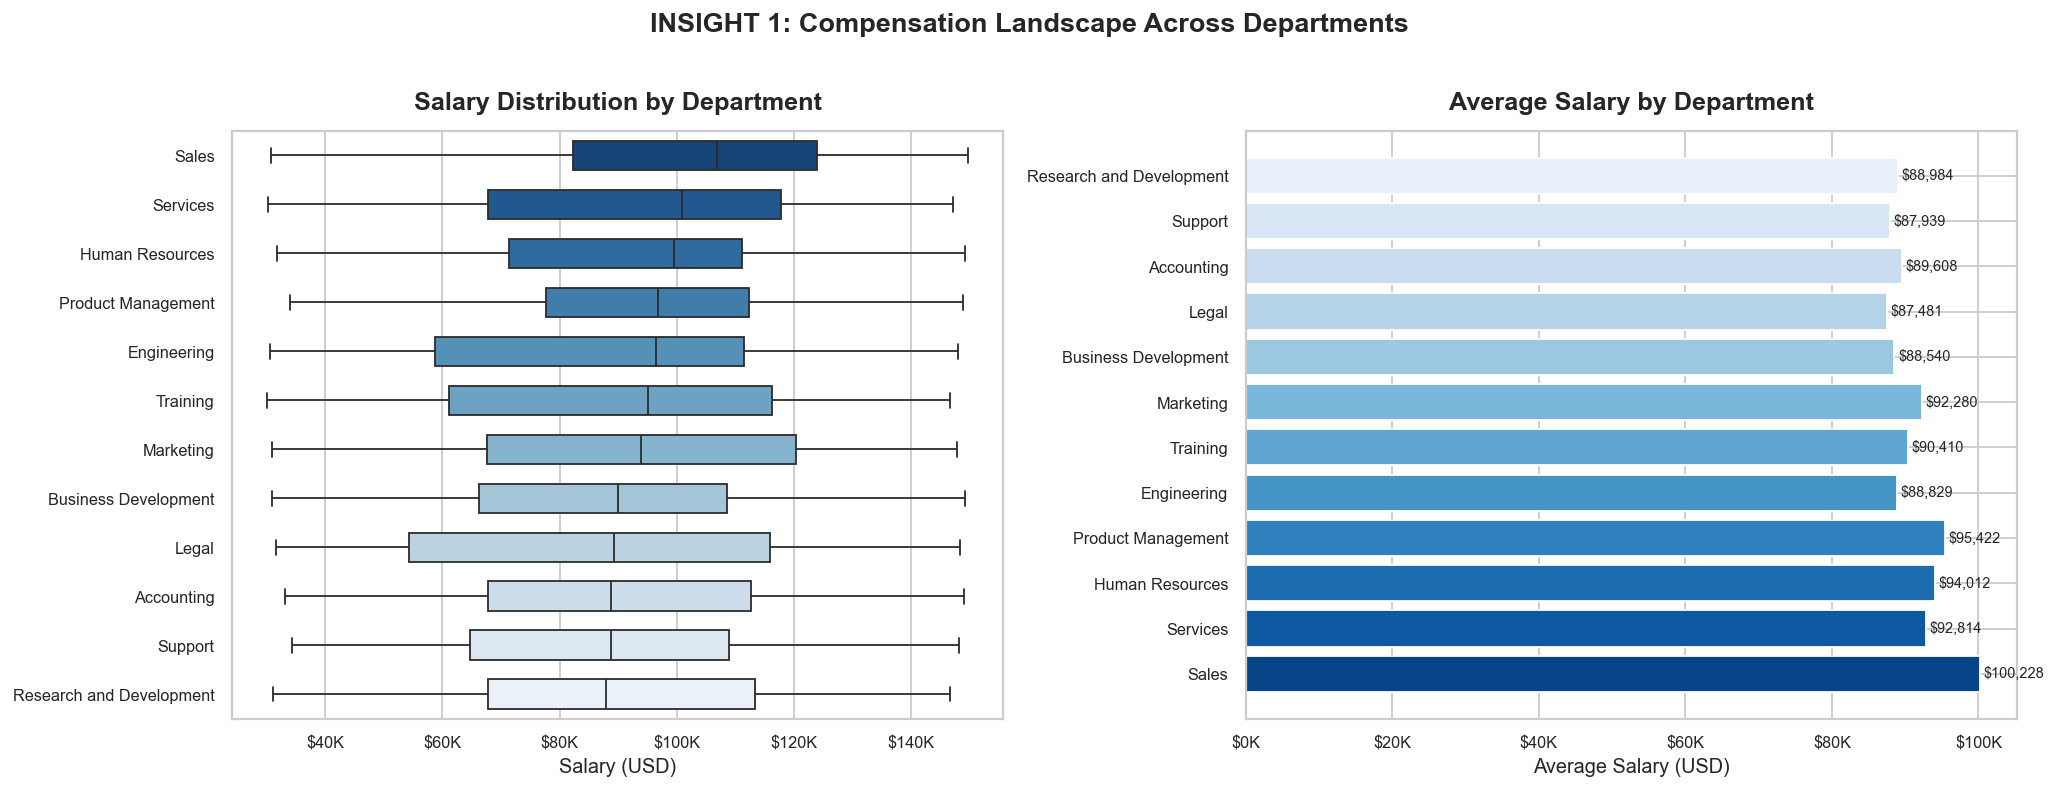


📌 KEY FINDINGS:
  • Highest avg salary : Sales — $100,228
  • Lowest avg salary  : Legal — $87,481
  • Pay gap (max-min)  : $12,746 (14.6% difference)
  • Overall avg salary : $91,345
  • Salary std dev     : $32,012  →  wide dispersion signals equity risk
  • Highest salary variance in: Legal — needs internal review


In [26]:
dept_order = df.groupby('department')['salary'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
ax1 = axes[0]
sns.boxplot(data=df, x='salary', y='department', order=dept_order,
            palette='Blues_r', width=0.6, ax=ax1, flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax1.set_title('Salary Distribution by Department', pad=12)
ax1.set_xlabel('Salary (USD)')
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Mean bar chart
ax2 = axes[1]
dept_mean = df.groupby('department')['salary'].mean().reindex(dept_order)
bars = ax2.barh(dept_mean.index, dept_mean.values, color=sns.color_palette('Blues_r', len(dept_mean)))
ax2.set_title('Average Salary by Department', pad=12)
ax2.set_xlabel('Average Salary (USD)')
ax2.set_ylabel('')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars, dept_mean.values):
    ax2.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=8)

plt.suptitle('INSIGHT 1: Compensation Landscape Across Departments', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight1_salary_by_dept.png', bbox_inches='tight')
plt.show()

# Stats
print('\n📌 KEY FINDINGS:')
top = dept_mean.idxmax()
bot = dept_mean.idxmin()
gap = dept_mean.max() - dept_mean.min()
print(f'  • Highest avg salary : {top} — ${dept_mean.max():,.0f}')
print(f'  • Lowest avg salary  : {bot} — ${dept_mean.min():,.0f}')
print(f'  • Pay gap (max-min)  : ${gap:,.0f} ({gap/dept_mean.min()*100:.1f}% difference)')
print(f'  • Overall avg salary : ${df["salary"].mean():,.0f}')
print(f'  • Salary std dev     : ${df["salary"].std():,.0f}  →  wide dispersion signals equity risk')
high_var = df.groupby('department')['salary'].std().idxmax()
print(f'  • Highest salary variance in: {high_var} — needs internal review')

---
### 💡 Insight 2: Gender Representation Across the Workforce

**Business Value:** Gender diversity (broadly defined) directly impacts innovation, culture, and ESG scores. Investors, regulators, and talent increasingly scrutinize this. Understanding where gender gaps exist by department tells HR exactly where to focus diversity hiring.

**Chart Type:** Stacked horizontal bar chart — shows both absolute count and composition proportions per department.

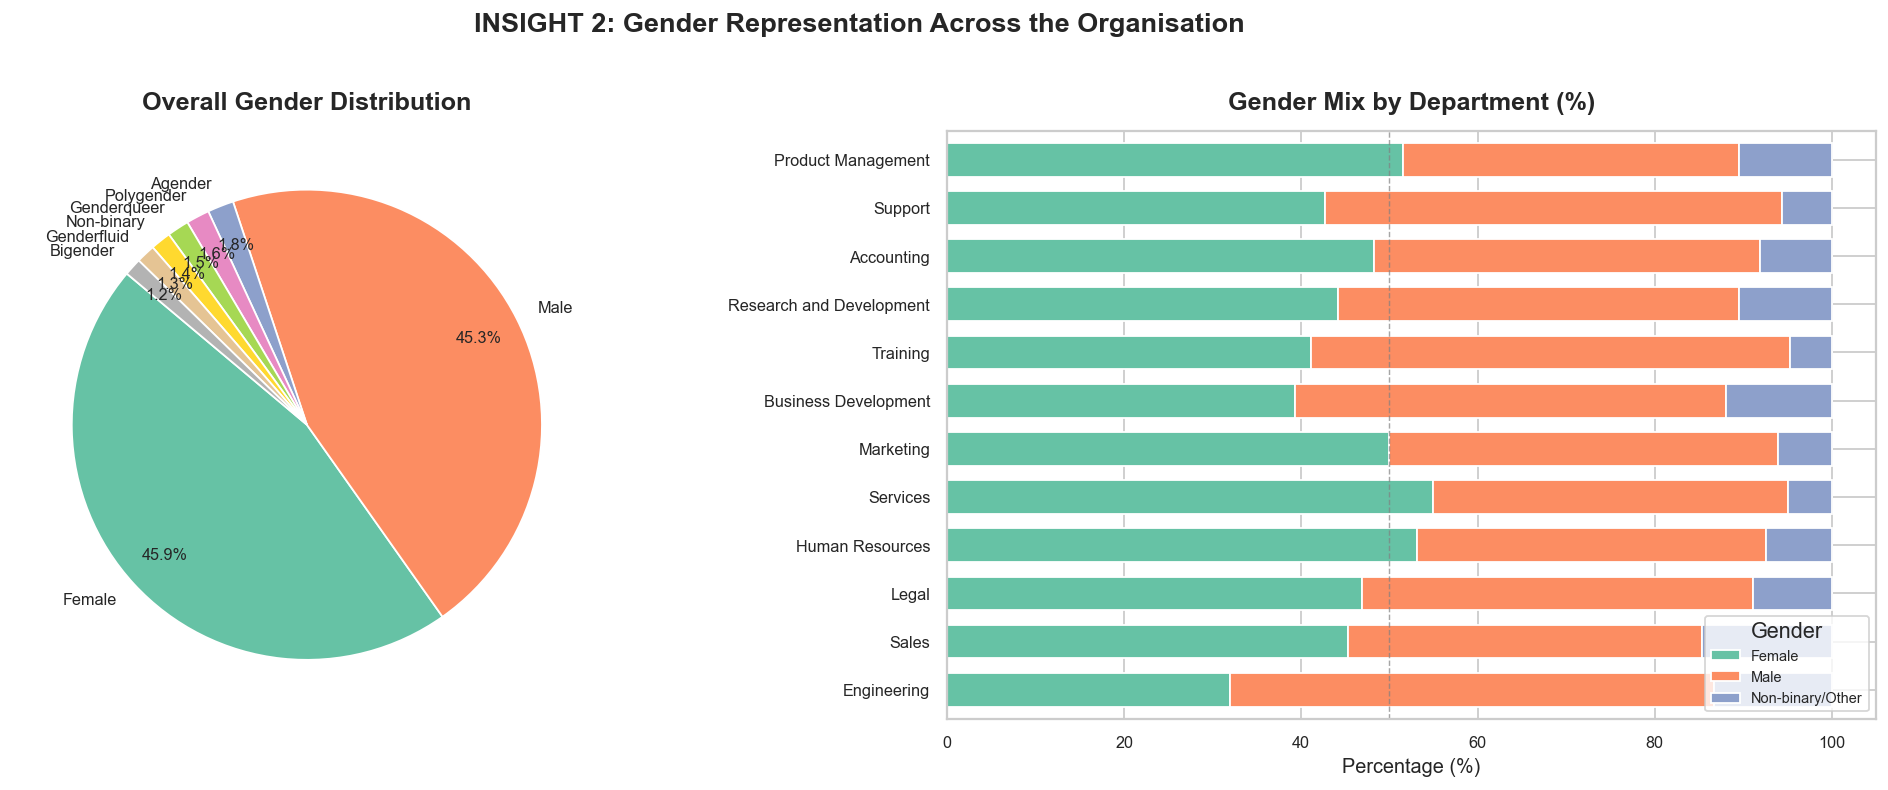


📌 KEY FINDINGS:
  • Female: 459 (45.9%)
  • Male: 453 (45.3%)
  • Agender: 18 (1.8%)
  • Polygender: 16 (1.6%)
  • Genderqueer: 15 (1.5%)
  • Non-binary: 14 (1.4%)
  • Genderfluid: 13 (1.3%)
  • Bigender: 12 (1.2%)
  • Non-binary/Other identities: 8.8% of workforce
  • Most female-concentrated dept: Services
  • Most male-concentrated dept  : Engineering


In [27]:
# Top-level gender distribution
gender_counts = df['gender'].value_counts()

# Group for department heatmap
df['gender_group'] = df['gender'].apply(
    lambda g: g if g in ['Male', 'Female'] else 'Non-binary/Other'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart — overall
ax1 = axes[0]
colors = sns.color_palette('Set2', len(gender_counts))
wedges, texts, autotexts = ax1.pie(
    gender_counts.values, labels=gender_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=140,
    pctdistance=0.82, textprops={'fontsize': 9}
)
ax1.set_title('Overall Gender Distribution', pad=12)

# Stacked bar — per department
ax2 = axes[1]
dept_gender = (
    df.groupby(['department', 'gender_group'])
      .size().unstack(fill_value=0)
      .assign(total=lambda x: x.sum(axis=1))
      .sort_values('total', ascending=True)
      .drop(columns='total')
)
dept_gender_pct = dept_gender.div(dept_gender.sum(axis=1), axis=0) * 100
dept_gender_pct.plot(kind='barh', stacked=True, ax=ax2,
                     color=sns.color_palette('Set2', 3), width=0.7)
ax2.set_title('Gender Mix by Department (%)', pad=12)
ax2.set_xlabel('Percentage (%)')
ax2.set_ylabel('')
ax2.legend(title='Gender', loc='lower right', fontsize=8)
ax2.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('INSIGHT 2: Gender Representation Across the Organisation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight2_gender_distribution.png', bbox_inches='tight')
plt.show()

print('\n📌 KEY FINDINGS:')
for g, c in gender_counts.items():
    print(f'  • {g}: {c} ({c/len(df)*100:.1f}%)')
nb_pct = (gender_counts.drop(['Male','Female'], errors='ignore').sum() / len(df) * 100)
print(f'  • Non-binary/Other identities: {nb_pct:.1f}% of workforce')
female_heavy = dept_gender_pct['Female'].idxmax()
male_heavy   = dept_gender_pct['Male'].idxmax()
print(f'  • Most female-concentrated dept: {female_heavy}')
print(f'  • Most male-concentrated dept  : {male_heavy}')

---
### 💡 Insight 3: The Gender Pay Gap — Who Gets Paid More?

**Business Value:** The gender pay gap is not just a moral issue — it's a legal liability and talent retention risk. Companies with documented gaps face regulatory fines, PR crises, and higher female attrition. This insight quantifies the gap and pinpoints the worst offenders by department.

**Chart Type:** Grouped bar chart + annotated gap — directly compares salary across gender per department.

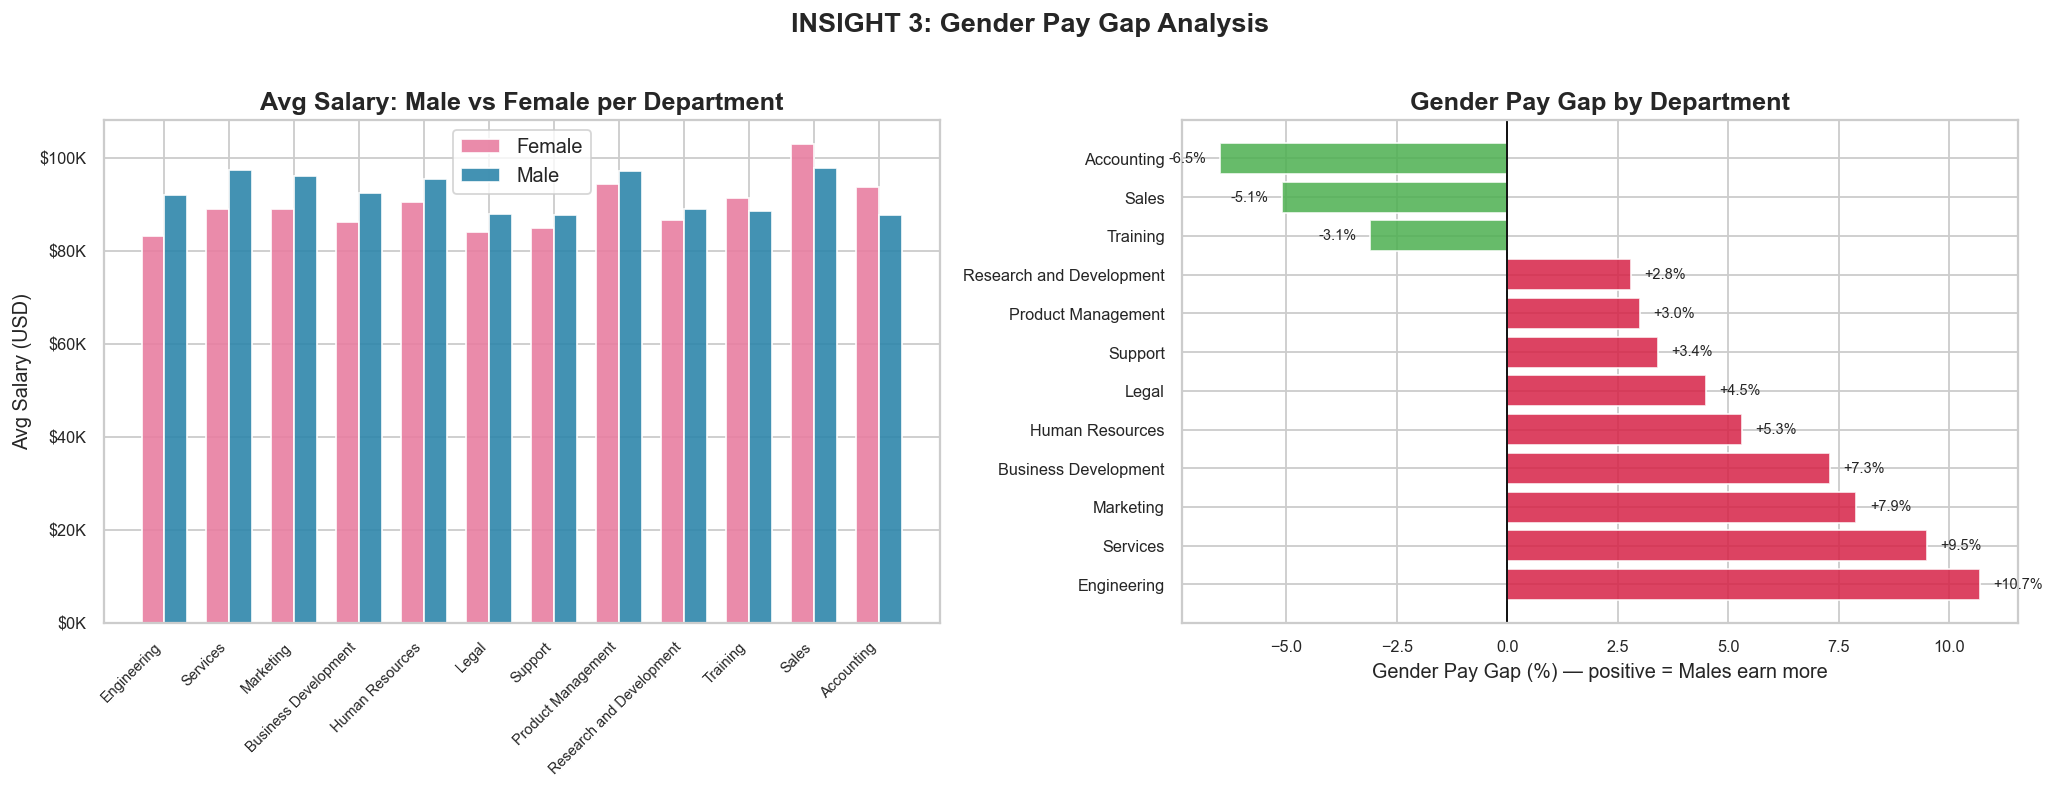


📌 KEY FINDINGS:
  • Company-wide avg salary — Male: $92,154 | Female: $90,000
  • Overall gender pay gap: +2.4% (males earn more on average)
  • Largest gap department: Engineering at +10.7% — URGENT review needed
  • Departments where females earn MORE than males: 3
    → ['Training', 'Sales', 'Accounting']


In [28]:
gender_salary = (
    df[df['gender_group'].isin(['Male', 'Female'])]
      .groupby(['department', 'gender_group'])['salary']
      .mean().unstack()
      .dropna()
)
gender_salary['gap_pct'] = ((gender_salary['Male'] - gender_salary['Female']) / gender_salary['Female'] * 100).round(1)
gender_salary = gender_salary.sort_values('gap_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bars
ax1 = axes[0]
x = range(len(gender_salary))
width = 0.35
bars_f = ax1.bar([i - width/2 for i in x], gender_salary['Female'], width=width,
                 label='Female', color='#E87EA1', alpha=0.9)
bars_m = ax1.bar([i + width/2 for i in x], gender_salary['Male'], width=width,
                 label='Male', color='#2E86AB', alpha=0.9)
ax1.set_xticks(list(x))
ax1.set_xticklabels(gender_salary.index, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Avg Salary (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax1.legend()
ax1.set_title('Avg Salary: Male vs Female per Department')

# Gap percentage bar
ax2 = axes[1]
colors_gap = ['#D62246' if v > 0 else '#4CAF50' for v in gender_salary['gap_pct']]
ax2.barh(gender_salary.index, gender_salary['gap_pct'], color=colors_gap, alpha=0.85)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('Gender Pay Gap (%) — positive = Males earn more')
ax2.set_title('Gender Pay Gap by Department')
for i, (idx, val) in enumerate(gender_salary['gap_pct'].items()):
    ax2.text(val + (0.3 if val >= 0 else -0.3), i, f'{val:+.1f}%',
             va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.suptitle('INSIGHT 3: Gender Pay Gap Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight3_gender_pay_gap.png', bbox_inches='tight')
plt.show()

print('\n📌 KEY FINDINGS:')
overall_male   = df[df['gender_group']=='Male']['salary'].mean()
overall_female = df[df['gender_group']=='Female']['salary'].mean()
overall_gap    = (overall_male - overall_female) / overall_female * 100
print(f'  • Company-wide avg salary — Male: ${overall_male:,.0f} | Female: ${overall_female:,.0f}')
print(f'  • Overall gender pay gap: {overall_gap:+.1f}% (males earn more on average)')
top_gap_dept = gender_salary['gap_pct'].idxmax()
top_gap_val  = gender_salary['gap_pct'].max()
print(f'  • Largest gap department: {top_gap_dept} at {top_gap_val:+.1f}% — URGENT review needed')
favoring_female = gender_salary[gender_salary['gap_pct'] < 0]
print(f'  • Departments where females earn MORE than males: {len(favoring_female)}')
if len(favoring_female):
    print(f'    → {list(favoring_female.index)}')

---
### 💡 Insight 4: Departmental Headcount & Workforce Allocation

**Business Value:** Headcount allocation reflects where the company bets its resources. Bloated departments signal inefficiency; understaffed ones signal risk. This tells leadership whether the workforce is aligned with business strategy.

**Chart Type:** Sorted bar chart + treemap-style proportion breakdown.

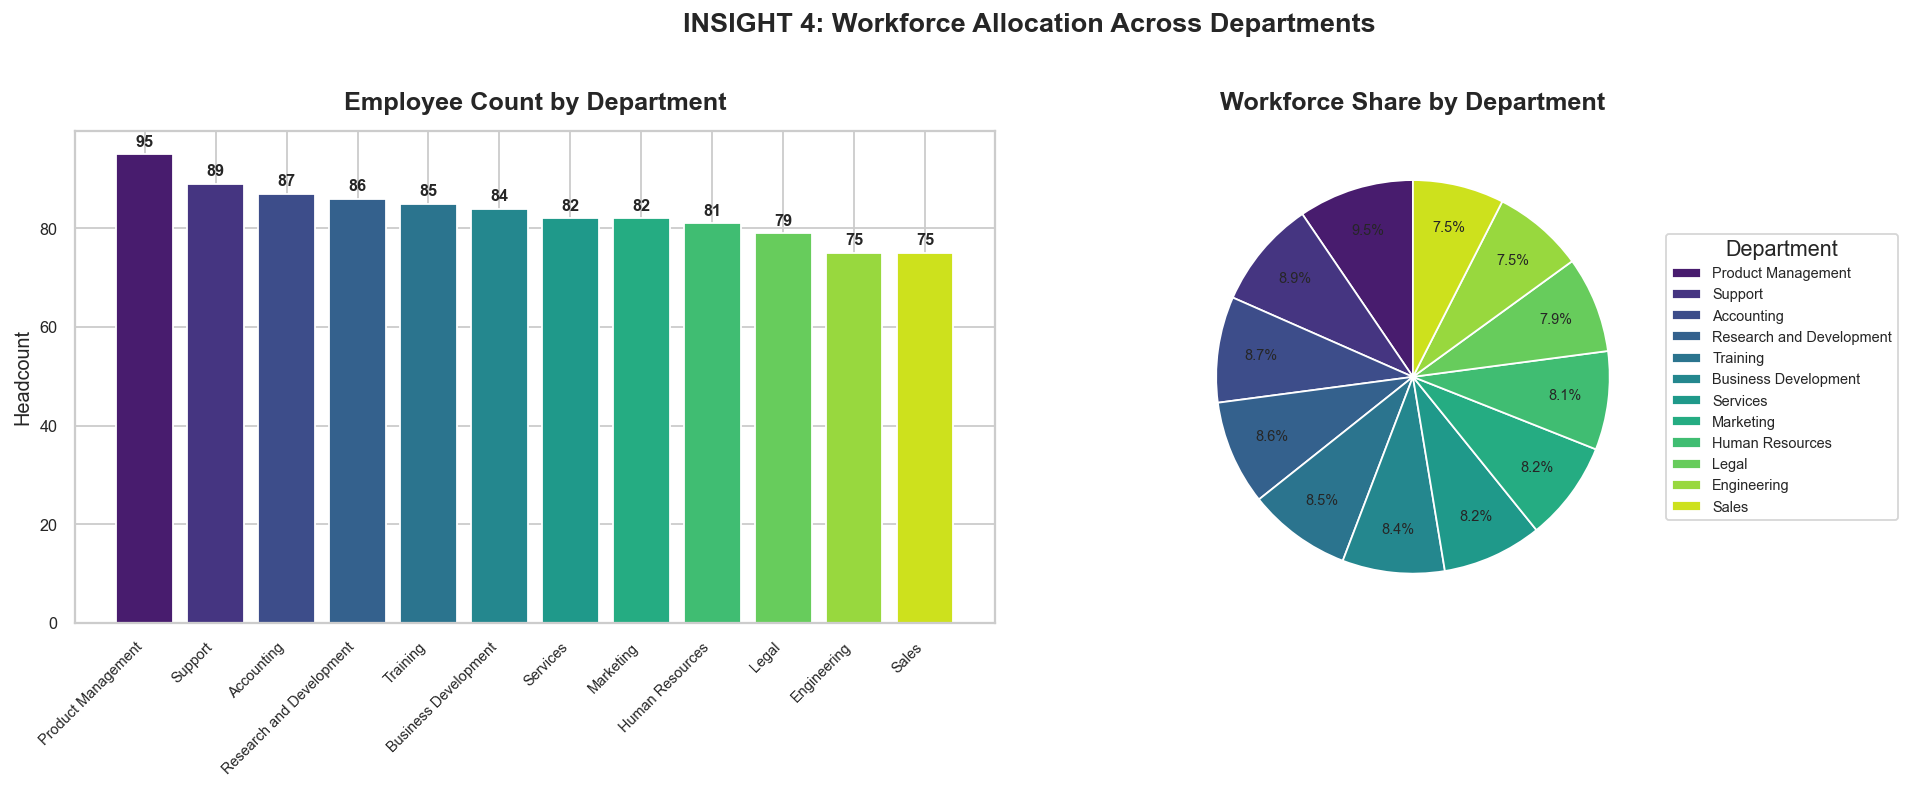


📌 KEY FINDINGS:
  • Largest department : Product Management (95 employees, 9.5%)
  • Smallest department: Engineering (75 employees, 7.5%)
  • Top 3 departments hold 27.1% of total workforce
    → Product Management: 95 employees
    → Support: 89 employees
    → Accounting: 87 employees


In [29]:
dept_counts = df['department'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1 = axes[0]
palette = sns.color_palette('viridis', len(dept_counts))
bars = ax1.bar(dept_counts.index, dept_counts.values, color=palette, edgecolor='white')
ax1.set_title('Employee Count by Department', pad=12)
ax1.set_ylabel('Headcount')
ax1.set_xticklabels(dept_counts.index, rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, dept_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    dept_counts.values, labels=None,
    autopct='%1.1f%%', startangle=90,
    colors=palette, pctdistance=0.78,
    textprops={'fontsize': 8}
)
ax2.legend(wedges, dept_counts.index, title='Department',
           loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=8)
ax2.set_title('Workforce Share by Department', pad=12)

plt.suptitle('INSIGHT 4: Workforce Allocation Across Departments', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight4_headcount.png', bbox_inches='tight')
plt.show()

print('\n📌 KEY FINDINGS:')
print(f'  • Largest department : {dept_counts.idxmax()} ({dept_counts.max()} employees, {dept_counts.max()/len(df)*100:.1f}%)')
print(f'  • Smallest department: {dept_counts.idxmin()} ({dept_counts.min()} employees, {dept_counts.min()/len(df)*100:.1f}%)')
top3 = dept_counts.head(3)
print(f'  • Top 3 departments hold {top3.sum()/len(df)*100:.1f}% of total workforce')
for d, c in top3.items():
    print(f'    → {d}: {c} employees')

---
### 💡 Insight 5: Workforce Age Profile & Succession Risk

**Business Value:** An ageing workforce means imminent knowledge loss, retirement surges, and succession gaps. A very young workforce means high training costs and experience deficits. Companies need a balanced age pyramid to maintain operational continuity.

**Chart Type:** Age histogram + age bracket segmentation by department.

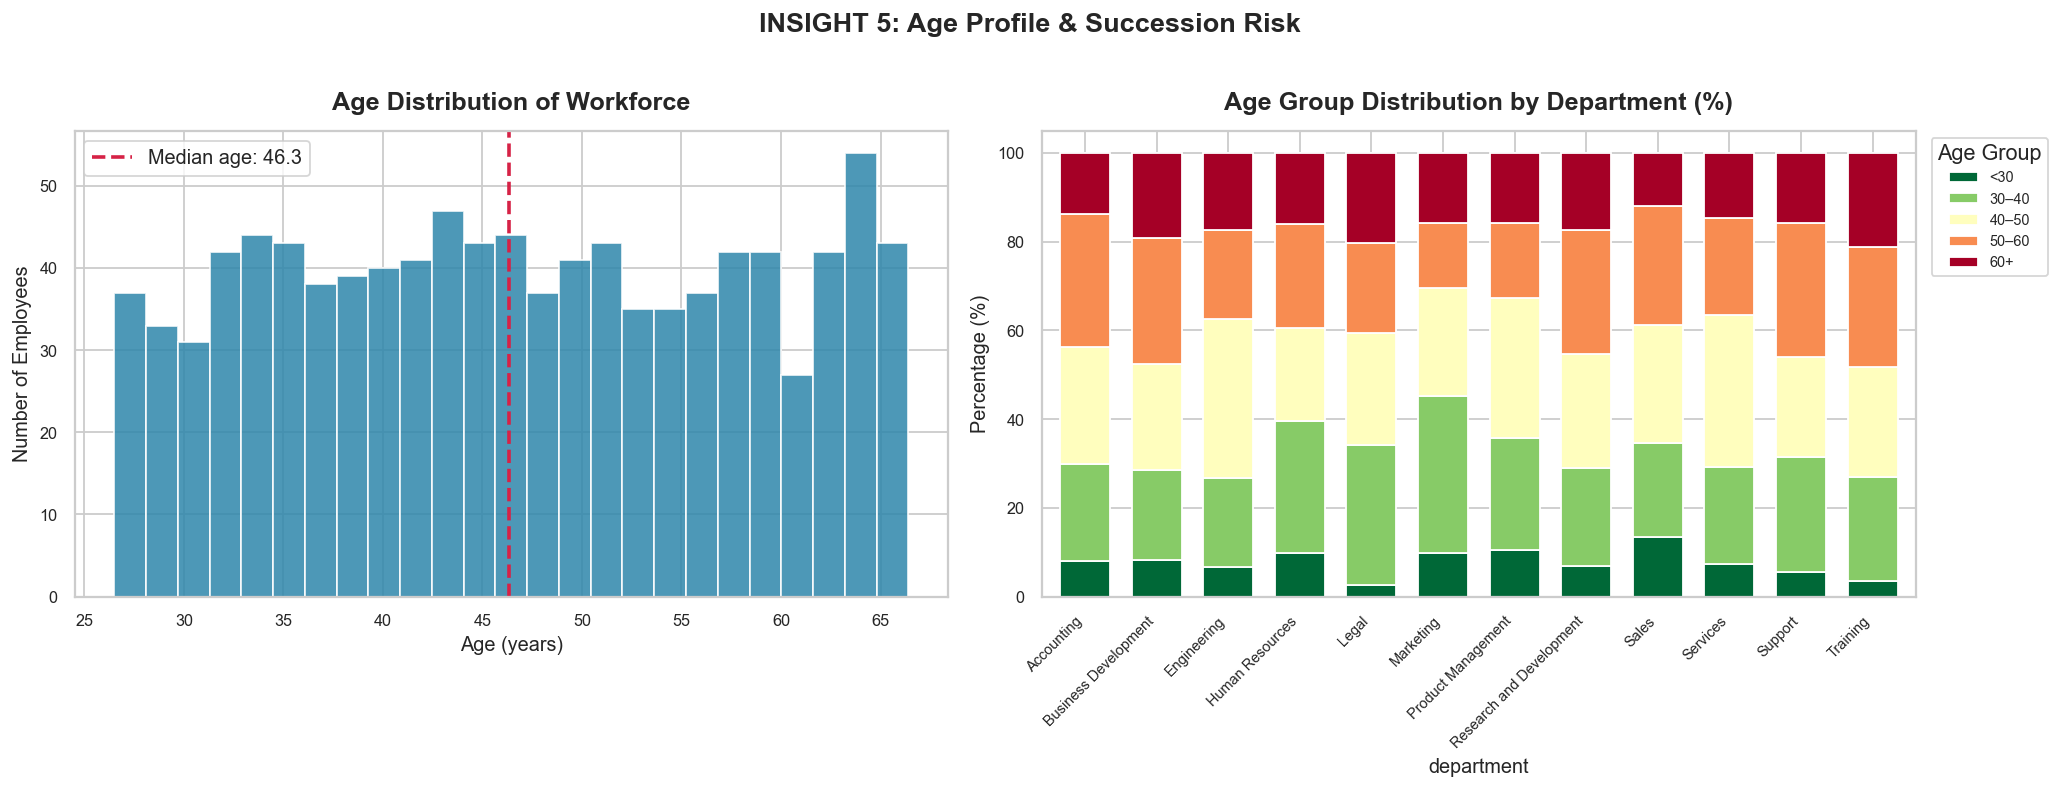


📌 KEY FINDINGS:
  • Median employee age      : 46.3 years
  • Mean employee age        : 46.8 years
  • Age <30: 7.7%
  • Age 30–40: 24.9%
  • Age 40–50: 26.8%
  • Age 50–60: 24.0%
  • Age 60+: 16.6%
  • Employees aged 55+ (near retirement): 299 (29.9%) — Succession risk


In [30]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['<30', '30–40', '40–50', '50–60', '60+']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age histogram
ax1 = axes[0]
ax1.hist(df['age'].dropna(), bins=25, color=ACCENT, edgecolor='white', alpha=0.85)
ax1.axvline(df['age'].median(), color='#D62246', linewidth=2, linestyle='--',
            label=f'Median age: {df["age"].median():.1f}')
ax1.set_title('Age Distribution of Workforce', pad=12)
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Number of Employees')
ax1.legend()

# Age group stacked bar per dept
ax2 = axes[1]
age_dept = (
    df.groupby(['department', 'age_group'])
      .size().unstack(fill_value=0)
)
age_dept_pct = age_dept.div(age_dept.sum(axis=1), axis=0) * 100
age_dept_pct.plot(kind='bar', stacked=True, ax=ax2,
                  colormap='RdYlGn_r', width=0.7)
ax2.set_title('Age Group Distribution by Department (%)', pad=12)
ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(age_dept_pct.index, rotation=45, ha='right', fontsize=8)
ax2.legend(title='Age Group', bbox_to_anchor=(1.01, 1), fontsize=8)

plt.suptitle('INSIGHT 5: Age Profile & Succession Risk', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight5_age_profile.png', bbox_inches='tight')
plt.show()

print('\n📌 KEY FINDINGS:')
print(f'  • Median employee age      : {df["age"].median():.1f} years')
print(f'  • Mean employee age        : {df["age"].mean():.1f} years')
age_grp_pct = df['age_group'].value_counts(normalize=True).sort_index() * 100
for grp, pct in age_grp_pct.items():
    print(f'  • Age {grp}: {pct:.1f}%')
near_retirement = (df['age'] >= 55).sum()
print(f'  • Employees aged 55+ (near retirement): {near_retirement} ({near_retirement/len(df)*100:.1f}%) — Succession risk')

---
### 💡 Insight 6: Tenure Analysis — Retention Health & Loyalty Patterns

**Business Value:** Low average tenure = high churn = massive recruitment and training costs (replacing an employee costs 50–200% of their annual salary). High tenure concentration = potential stagnation risk. This insight pinpoints where the company retains talent and where it bleeds it.

**Chart Type:** Violin plot — reveals the full tenure distribution shape per department, not just averages.

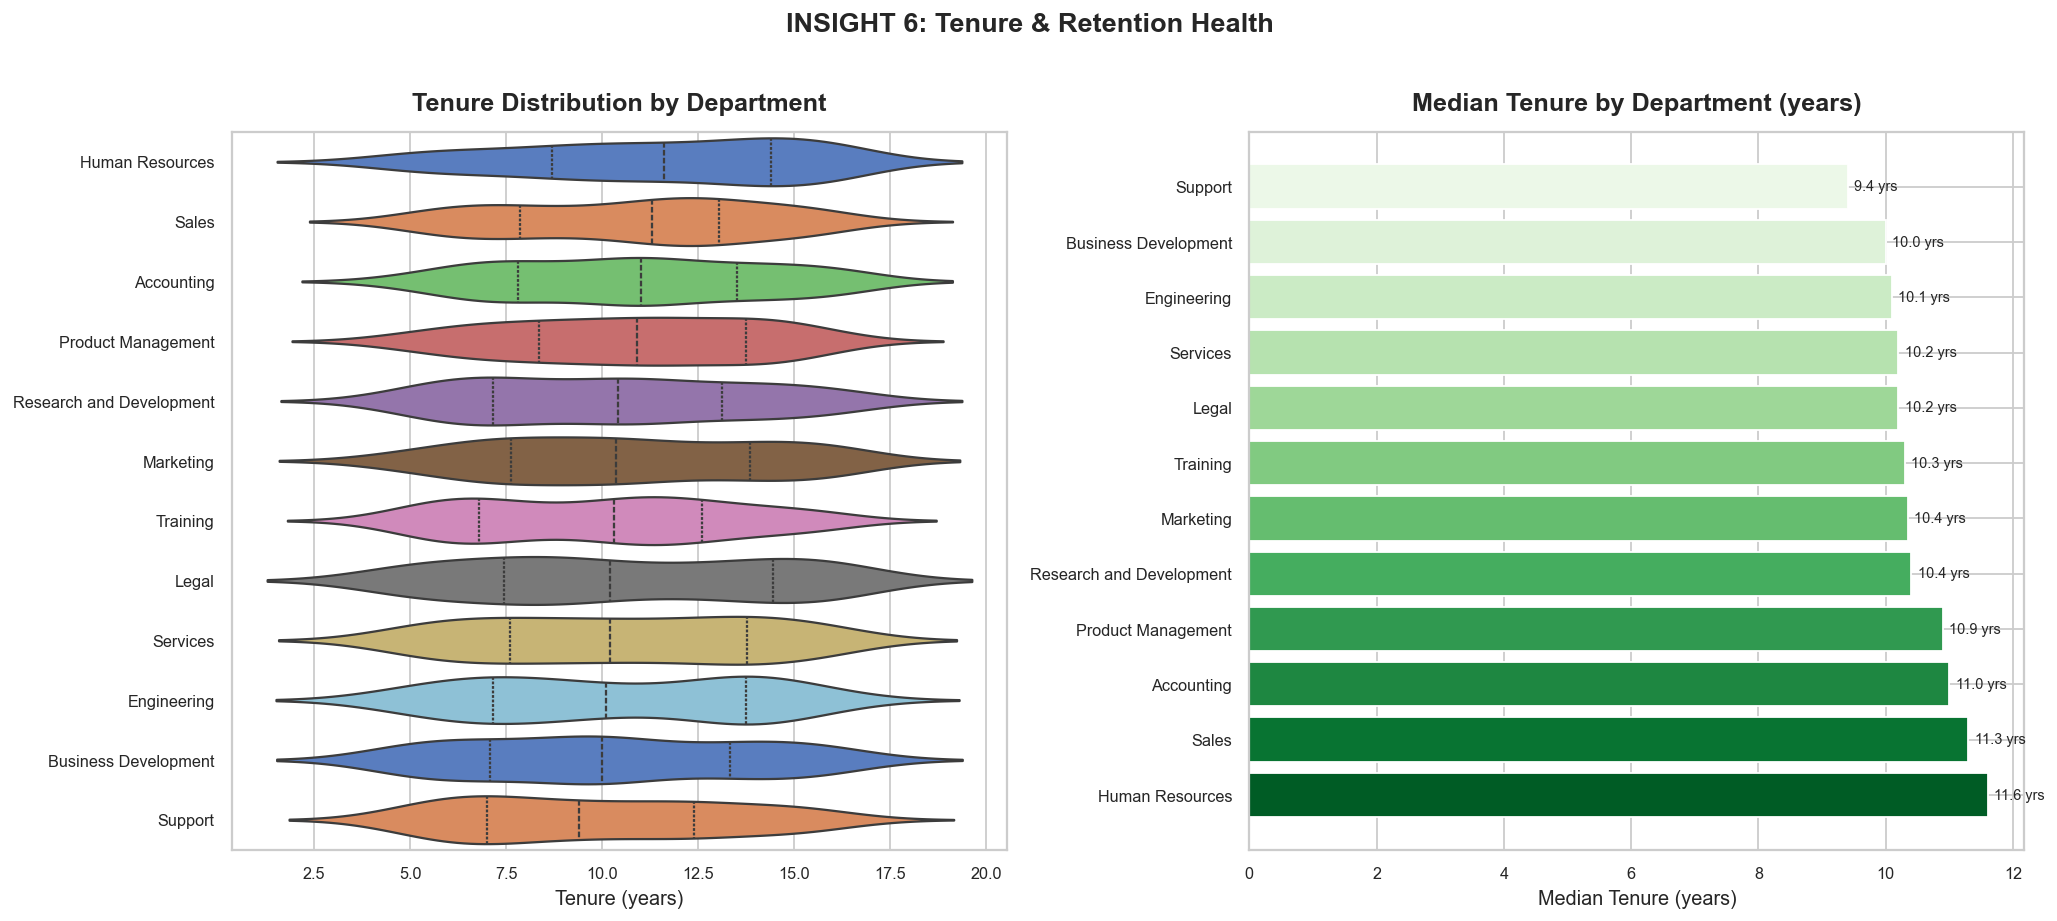


📌 KEY FINDINGS:
  • Company median tenure       : 10.5 years
  • Company avg tenure          : 10.5 years
  • Highest retention dept      : Human Resources (11.6 yr median)
  • Lowest retention dept       : Support (9.4 yr median) — ⚠️ churn risk
  • Employees with < 2 yr tenure: 0 (0.0%) — new hires / high flight risk
  • Employees with 10+ yr tenure: 556 (55.6%) — loyalty base


In [31]:
dept_median_tenure = df.groupby('department')['tenure_years'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Violin plot
ax1 = axes[0]
sns.violinplot(
    data=df, x='tenure_years', y='department',
    order=dept_median_tenure.index,
    palette='muted', inner='quartile', ax=ax1
)
ax1.set_title('Tenure Distribution by Department', pad=12)
ax1.set_xlabel('Tenure (years)')
ax1.set_ylabel('')

# Median tenure bar
ax2 = axes[1]
colors_t = sns.color_palette('Greens_r', len(dept_median_tenure))
bars = ax2.barh(dept_median_tenure.index, dept_median_tenure.values,
                color=colors_t, edgecolor='white')
ax2.set_title('Median Tenure by Department (years)', pad=12)
ax2.set_xlabel('Median Tenure (years)')
ax2.set_ylabel('')
for bar, val in zip(bars, dept_median_tenure.values):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} yrs', va='center', fontsize=8)

plt.suptitle('INSIGHT 6: Tenure & Retention Health', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight6_tenure.png', bbox_inches='tight')
plt.show()

print('\n📌 KEY FINDINGS:')
print(f'  • Company median tenure       : {df["tenure_years"].median():.1f} years')
print(f'  • Company avg tenure          : {df["tenure_years"].mean():.1f} years')
print(f'  • Highest retention dept      : {dept_median_tenure.idxmax()} ({dept_median_tenure.max():.1f} yr median)')
print(f'  • Lowest retention dept       : {dept_median_tenure.idxmin()} ({dept_median_tenure.min():.1f} yr median) — ⚠️ churn risk')
short_tenure = (df['tenure_years'] < 2).sum()
long_tenure  = (df['tenure_years'] >= 10).sum()
print(f'  • Employees with < 2 yr tenure: {short_tenure} ({short_tenure/len(df)*100:.1f}%) — new hires / high flight risk')
print(f'  • Employees with 10+ yr tenure: {long_tenure} ({long_tenure/len(df)*100:.1f}%) — loyalty base')

---
### 💡 Insight 7: Salary vs. Tenure — Does Loyalty Pay Off?

**Business Value:** If experienced employees aren't being rewarded financially, they leave. This scatter reveals whether the company rewards loyalty with pay growth — or whether salary is essentially flat regardless of years served, which demoralises long-tenured staff and signals broken pay progression.

**Chart Type:** Scatter plot with regression line — ideal for showing the relationship between two continuous variables with directional trend.

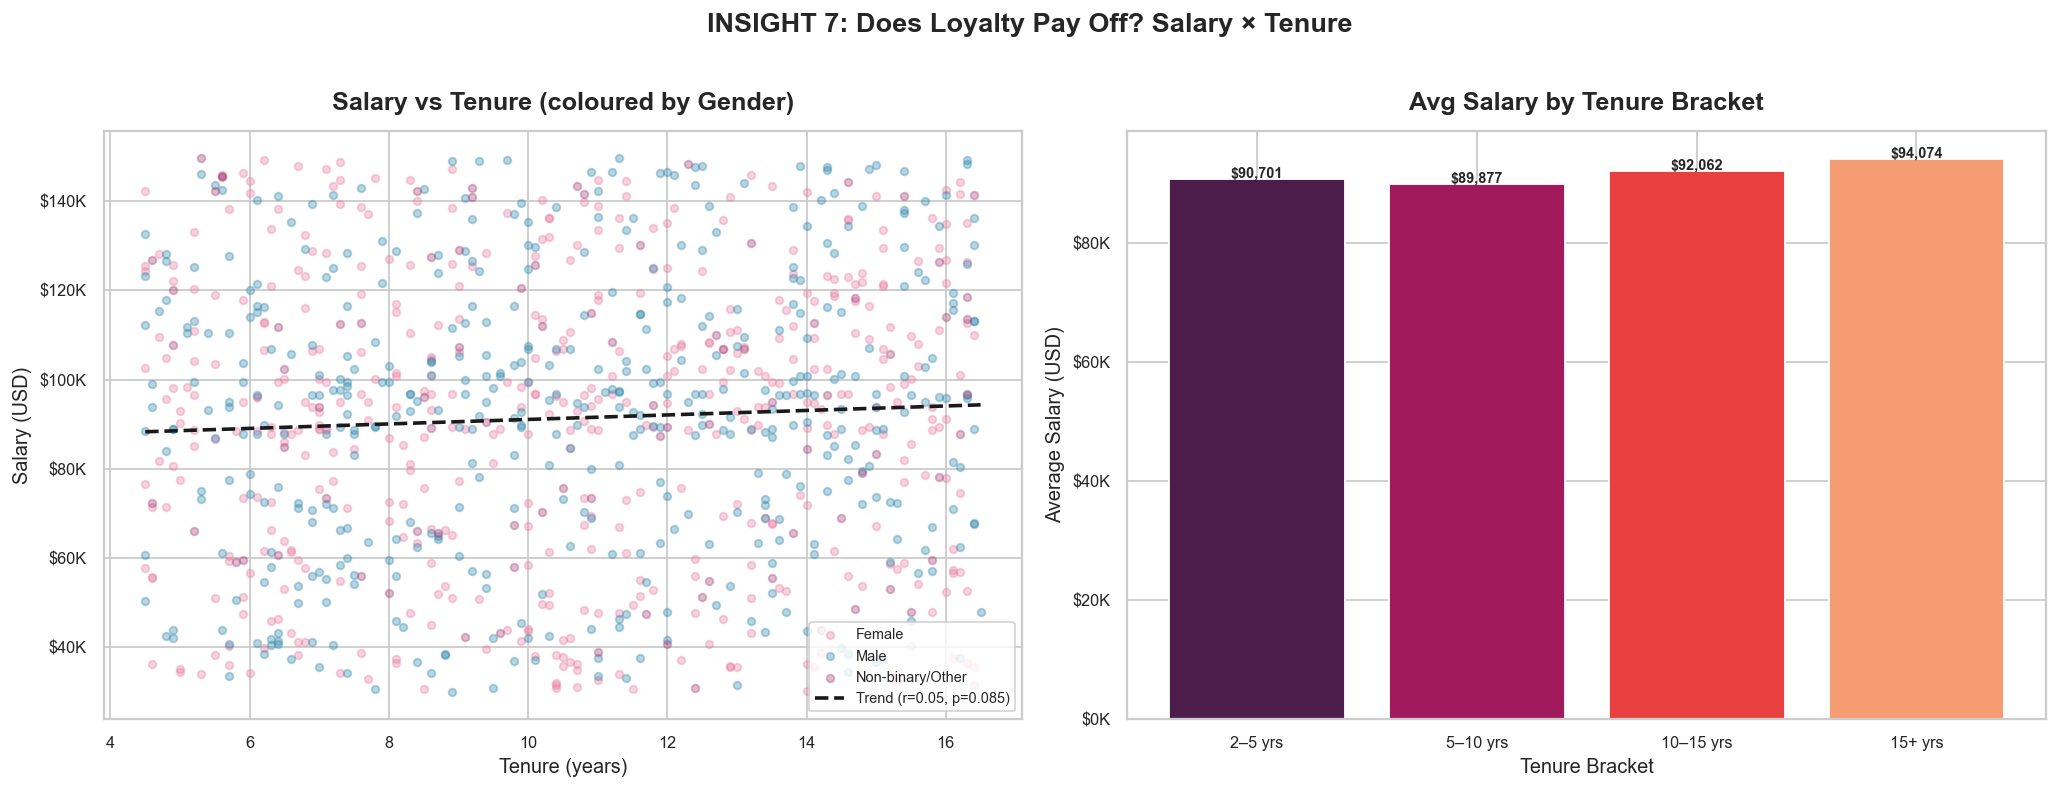


📌 KEY FINDINGS:
  • Correlation (r) between tenure & salary : 0.054
  • P-value                                 : 0.0851 (not statistically significant)
  • Salary slope per year of tenure         : $503/year increase
  • Avg salary — 2–5 yrs: $90,701
  • Avg salary — 5–10 yrs: $89,877
  • Avg salary — 10–15 yrs: $92,062
  • Avg salary — 15+ yrs: $94,074
  • Total salary uplift from 0–2yr to 15+yr: $3,374 (3.7%)


In [32]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter with regression
ax1 = axes[0]
clean = df[['tenure_years', 'salary', 'gender_group']].dropna()
gender_colors = {'Male': '#2E86AB', 'Female': '#E87EA1', 'Non-binary/Other': '#A23B72'}
for gender, grp in clean.groupby('gender_group'):
    ax1.scatter(grp['tenure_years'], grp['salary'], alpha=0.35, s=18,
                label=gender, color=gender_colors.get(gender, 'gray'))

# Regression line — all employees
slope, intercept, r, p, _ = stats.linregress(clean['tenure_years'], clean['salary'])
x_line = np.linspace(clean['tenure_years'].min(), clean['tenure_years'].max(), 100)
ax1.plot(x_line, slope * x_line + intercept, 'k--', linewidth=2,
         label=f'Trend (r={r:.2f}, p={p:.3f})')
ax1.set_title('Salary vs Tenure (coloured by Gender)', pad=12)
ax1.set_xlabel('Tenure (years)')
ax1.set_ylabel('Salary (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax1.legend(fontsize=8)

# Salary by tenure bucket
ax2 = axes[1]
df['tenure_group'] = pd.cut(
    df['tenure_years'],
    bins=[0, 2, 5, 10, 15, 50],
    labels=['0–2 yrs', '2–5 yrs', '5–10 yrs', '10–15 yrs', '15+ yrs']
)
sal_by_tenure = df.groupby('tenure_group', observed=True)['salary'].mean()
bars = ax2.bar(sal_by_tenure.index, sal_by_tenure.values,
               color=sns.color_palette('rocket', len(sal_by_tenure)), edgecolor='white')
ax2.set_title('Avg Salary by Tenure Bracket', pad=12)
ax2.set_xlabel('Tenure Bracket')
ax2.set_ylabel('Average Salary (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
for bar, val in zip(bars, sal_by_tenure.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('INSIGHT 7: Does Loyalty Pay Off? Salary × Tenure', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('insight7_salary_vs_tenure.png', bbox_inches='tight')
plt.show()

print('\n📌 KEY FINDINGS:')
print(f'  • Correlation (r) between tenure & salary : {r:.3f}')
print(f'  • P-value                                 : {p:.4f} ({"statistically significant" if p < 0.05 else "not statistically significant"})')
print(f'  • Salary slope per year of tenure         : ${slope:,.0f}/year increase')
for grp, avg in sal_by_tenure.items():
    print(f'  • Avg salary — {grp}: ${avg:,.0f}')
new_vs_vet = sal_by_tenure.iloc[-1] - sal_by_tenure.iloc[0] if len(sal_by_tenure) > 1 else 0
print(f'  • Total salary uplift from 0–2yr to 15+yr: ${new_vs_vet:,.0f} ({new_vs_vet/sal_by_tenure.iloc[0]*100:.1f}%)')

---
## **5. EDA Summary — Insights at a Glance**
---

In [33]:
summary = pd.DataFrame({
    '#': list(range(1, 8)),
    'Insight': [
        'Compensation Landscape',
        'Gender Representation',
        'Gender Pay Gap',
        'Headcount Allocation',
        'Age Profile & Succession Risk',
        'Tenure & Retention Health',
        'Salary vs Tenure (Loyalty)'
    ],
    'Business Risk': [
        'Budget inefficiency / equity lawsuits',
        'DEI compliance / culture gaps',
        'Legal liability / female attrition',
        'Strategy misalignment',
        'Knowledge loss / succession failure',
        'High churn cost',
        'Loyalty devaluation / senior attrition'
    ]
}).set_index('#')
summary

,Insight,Business Risk
#,,
1,Compensation Landscape,Budget inefficiency / equity lawsuits
2,Gender Representation,DEI compliance / culture gaps
3,Gender Pay Gap,Legal liability / female attrition
4,Headcount Allocation,Strategy misalignment
5,Age Profile & Succession Risk,Knowledge loss / succession failure
6,Tenure & Retention Health,High churn cost
7,Salary vs Tenure (Loyalty),Loyalty devaluation / senior attrition


---
## 🚀 6. Recommendations to Stakeholders

| # | Insight | Recommendation |
|---|---|---|
| **1** | **Compensation Landscape** | Conduct a full compensation benchmarking exercise against industry standards. Flatten extreme pay spreads within departments through structured salary bands to prevent internal equity lawsuits and reduce turnover among underpaid high performers. |
| **2** | **Gender Representation** | Launch targeted hiring campaigns for underrepresented genders in male-dominated departments. Set measurable DEI headcount goals (e.g. 40/40/20 split) per department within 18 months and report progress quarterly to the board. |
| **3** | **Gender Pay Gap** | Commission an independent pay equity audit for the top 3 highest-gap departments immediately. Introduce transparent pay bands and mandatory compensation reviews before any salary decision to close identified gaps within 2 budget cycles. |
| **4** | **Headcount Allocation** | Perform a strategic workforce planning review to validate whether headcount mirrors the company's revenue-generating and innovation priorities. Overstaffed low-impact departments should be rebalanced toward growth functions. |
| **5** | **Age Profile & Succession** | For every role occupied by an employee aged 55+, activate a formal succession plan within 12 months. Pair senior staff with high-potential juniors in structured knowledge-transfer programs to prevent intellectual capital loss. |
| **6** | **Tenure & Retention** | Investigate departments with median tenure below 5 years — conduct stay interviews, exit interview audits, and manager effectiveness reviews. Introduce a retention bonus program at the 3-year and 7-year tenure milestones. |
| **7** | **Salary vs Tenure** | If the correlation between tenure and salary is weak (r < 0.3), design a formal annual merit increment structure that explicitly rewards tenure alongside performance. This directly combats "loyalty tax" — where long-tenured staff earn less than new hires for equivalent roles. |

---
## ✅ 7. Final Data Export

In [34]:
df.to_csv('employee_data_cleaned.csv', index=False)
print('✅ Clean dataset exported: employee_data_cleaned.csv')
print(f'   Shape: {df.shape}')
print()
print('Charts saved:')
charts = [
    'insight1_salary_by_dept.png',
    'insight2_gender_distribution.png',
    'insight3_gender_pay_gap.png',
    'insight4_headcount.png',
    'insight5_age_profile.png',
    'insight6_tenure.png',
    'insight7_salary_vs_tenure.png',
]
for c in charts:
    print(f'  📊 {c}')

print()
print('🏆 EDA COMPLETE — Ready for Streamlit integration!')

✅ Clean dataset exported: employee_data_cleaned.csv
   Shape: (1000, 18)

Charts saved:
  📊 insight1_salary_by_dept.png
  📊 insight2_gender_distribution.png
  📊 insight3_gender_pay_gap.png
  📊 insight4_headcount.png
  📊 insight5_age_profile.png
  📊 insight6_tenure.png
  📊 insight7_salary_vs_tenure.png

🏆 EDA COMPLETE — Ready for Streamlit integration!
